# Quantized Target with `partition_tree.skpro`

This notebook shows how to use the skpro `PartitionTreeRegressor` when the target lives on a fixed lattice, such as values rounded to the nearest 0.25.

The key step is passing a quantized target override through `dtype_overrides` with `Domain.quantized_continuous(resolution)`.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

from partition_tree import Domain
from partition_tree.skpro import PartitionTreeRegressor

In [8]:
rng = np.random.default_rng(42)
resolution = 0.25
n_samples = 500

x1 = rng.uniform(-3.0, 3.0, size=n_samples)
x2 = rng.normal(loc=0.0, scale=1.0, size=n_samples)
signal = 3.0 + 1.8 * np.sin(x1) + 0.7 * x2
noise = rng.normal(scale=0.20, size=n_samples)
y_raw = signal + noise
y_quantized = np.round(y_raw / resolution) * resolution

X = pd.DataFrame({"x1": x1, "x2": x2})
y = pd.DataFrame({"target": y_quantized})

alignment_error = np.abs((y["target"] / resolution) - np.round(y["target"] / resolution)).max()
print(f"max alignment error: {alignment_error:.2e}")
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

max alignment error: 0.00e+00
   target
0    5.50
1    2.50
2    5.00
3    4.75
4    1.75


## Fit a probabilistic tree with a quantized target

For a single-target skpro regression problem, the wrapper keeps the target column name as `target`, so the override key must use that same name.

In [27]:
model = PartitionTreeRegressor(
    max_leaves=4000,
    max_depth=600,
    min_samples_xy=0,
    min_samples_x=50,
    min_samples_y=0,
    min_samples_split=1,
    min_volume_fraction=0,
    random_state=42,
    dtype_overrides={"target": Domain.quantized_continuous(resolution)},
)
model.fit(X_train, y_train)

root_partitions = model.partition_tree_.get_nodes_info()[0]["partitions"]
root_partitions["target"]

{'type': 'quantized_continuous',
 'low': -1.875,
 'high': 7.125,
 'resolution': 0.25,
 'lower_closed': True,
 'upper_closed': True}

In [28]:
dist = model.predict_proba(X_test)
mean_pred = model.predict(X_test)["target"]
lower_80 = dist.ppf(0.10)["target"]
upper_80 = dist.ppf(0.90)["target"]

summary = pd.DataFrame({
    "y_true": y_test["target"],
    "mean": mean_pred,
    "p10": lower_80,
    "p90": upper_80,
}).head(10)
summary

,y_true,mean,p10,p90
361,3.00,3.713110,2.315500,5.842628
73,0.75,1.541523,1.169308,1.871176
374,1.50,1.711535,1.208367,2.521245
155,4.50,4.022503,3.400502,4.746518
104,6.00,4.319656,2.467867,5.655662
394,1.25,1.133886,0.312259,2.187634
377,1.00,1.588658,0.398932,2.964457
124,2.75,1.856689,1.409734,2.353638
68,3.00,1.856689,1.409734,2.353638
450,2.50,1.856689,1.409734,2.353638


In [29]:
coverage_80 = ((y_test["target"] >= lower_80) & (y_test["target"] <= upper_80)).mean()
mae = mean_absolute_error(y_test["target"], mean_pred)

print(f"MAE: {mae:.3f}")
print(f"80% prediction interval coverage: {coverage_80:.1%}")

MAE: 0.539
80% prediction interval coverage: 74.4%


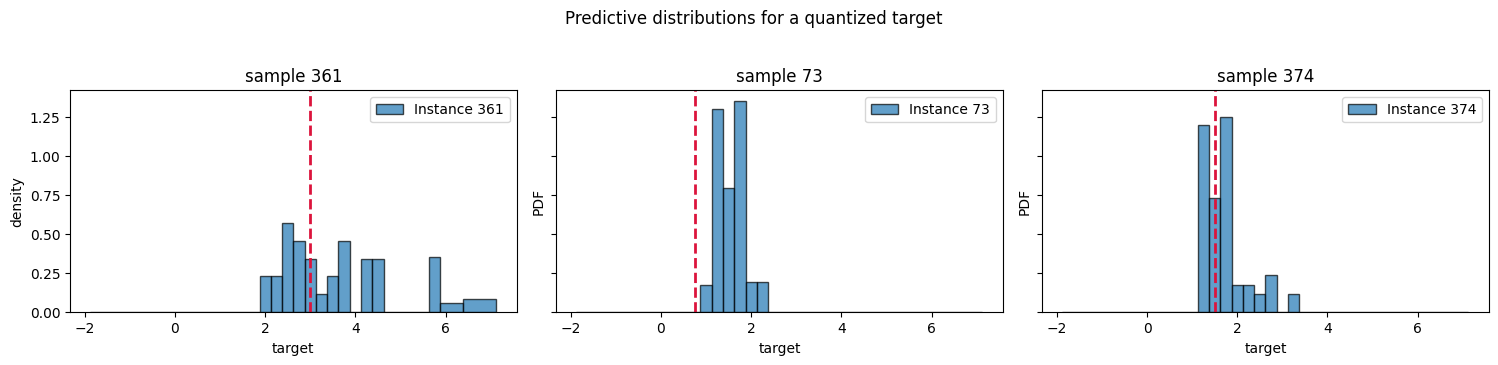

In [30]:
rows = list(X_test.index[:3])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)

for ax, row_idx in zip(axes, rows):
    dist_single = dist.loc[row_idx]
    dist_single.plot(ax=ax, alpha=0.7)
    ax.axvline(y_test.loc[row_idx, "target"], color="crimson", linestyle="--", linewidth=2)
    ax.set_title(f"sample {row_idx}")
    ax.set_xlabel("target")

axes[0].set_ylabel("density")
fig.suptitle("Predictive distributions for a quantized target", y=1.03)
plt.tight_layout()
plt.show()

In [11]:
dist_single.loc[73]

IntervalDistribution(columns=Index(['target'], dtype='object'),
                     index=Index([374], dtype='int64'),
                     intervals=[[(-1.875, 0.625), (0.625, 2.375),
                                 (2.375, 5.375), (5.375, 7.125)]],
                     pdf_values=[array([0.00144872, 0.52783759, 0.02301354, 0.0020696 ])])

In [18]:
y_test.sort_values("target")

,target
262,-0.00
15,0.00
408,0.25
148,0.25
172,0.25
...,...
433,5.50
356,6.00
290,6.00
104,6.00
